# 01 · Baseline Inference — *the model has no word for it*

**Module 4 · Unit 3 · Session 1**

Before training anything, establish the gap. This notebook runs a **stock YOLOv8**,
pretrained on COCO's 80 everyday classes, over building façades and asks the AECO
reality check from Session 1: *did it detect what we actually care about?*

The answer is no, and the reason is the whole justification for the rest of the
project. COCO contains `toothbrush`, `hair drier` and `teddy bear`. It contains no
`curtain_wall`, no `louvre_screen`, no `balcony`. A model cannot detect a class it
has never been given a word for.

**Runtime:** ~2 minutes, CPU is fine. No GPU, no account, no API key.


In [1]:
# ── CELL 1 ── Environment bootstrap. Run this first, every time.
# Works in Colab (clones the repo) and locally (uses the repo you are in).
import os, subprocess, sys, pathlib

REPO_URL = "https://github.com/OmarEAbdelaal/ZIGURAT-AI-AECO-Masters_Group-2.git"
SUBDIR   = "m4u3-facade-ve-vision"   # set to "" if the project is at the repo root

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    root = pathlib.Path('/content') / pathlib.Path(REPO_URL).stem
    if not root.exists():
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(root)], check=True)
    PROJECT = root / SUBDIR if SUBDIR else root
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                    str(PROJECT / 'requirements.txt')], check=True)
else:
    here = pathlib.Path.cwd()
    PROJECT = next((p for p in [here, *here.parents] if (p / 'src' / 'config.py').exists()), here)

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / 'src'))
print('project root :', PROJECT)

import config as C
print()
print(C.summary())


project root : /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision



dataset source   : synthetic
roboflow project : (not configured)
classes (5)     : window, curtain_wall, door, balcony, louvre_screen
model            : yolov8n.pt
epochs/batch/imgsz: 30 / 16 / 640
seed             : 42
conf / iou       : 0.35 / 0.5
ultralytics      : 8.4.157
torch            : 2.14.0+cu130
device           : CPU only
python           : 3.11.15 on Linux-6.18.44-fc-v37-x86_64-with-glibc2.39


## 1 · Get façade images to test on

Uses whatever is in `data/new_images/`. If that is empty, it generates held-out
procedural elevations so the notebook runs for a stranger with no data of their own.


In [2]:
from pathlib import Path

imgs = sorted(p for p in C.NEW_IMAGES_DIR.glob('*')
              if p.suffix.lower() in ('.jpg', '.jpeg', '.png'))
if not imgs:
    import synthetic_facades
    synthetic_facades.build_new_images(C.NEW_IMAGES_DIR, n=5)
    imgs = sorted(p for p in C.NEW_IMAGES_DIR.glob('*')
                  if p.suffix.lower() in ('.jpg', '.jpeg', '.png'))

print(f'{len(imgs)} test images')
for p in imgs:
    print(' ', p.name)


5 test images
  unseen_facade_01.jpg
  unseen_facade_02.jpg
  unseen_facade_03.jpg
  unseen_facade_04.jpg
  unseen_facade_05.jpg


## 2 · What does COCO actually know?


In [3]:
from ultralytics import YOLO

coco = YOLO('yolov8n.pt')
names = list(coco.names.values())
print(f'COCO classes: {len(names)}')
print()

wanted = ['window', 'curtain_wall', 'door', 'balcony', 'louvre_screen',
          'facade', 'glazing', 'wall']
for w in wanted:
    hit = [n for n in names if w in n.lower()]
    print(f"  {w:<16} -> {hit if hit else 'NOT IN COCO'}")

print()
print('what it does have, for contrast:')
print(' ', ', '.join(names[70:80]))


COCO classes: 80

  window           -> NOT IN COCO
  curtain_wall     -> NOT IN COCO
  door             -> NOT IN COCO
  balcony          -> NOT IN COCO
  louvre_screen    -> NOT IN COCO
  facade           -> NOT IN COCO
  glazing          -> NOT IN COCO
  wall             -> NOT IN COCO

what it does have, for contrast:
  toaster, sink, refrigerator, book, clock, vase, scissors, teddy bear, hair drier, toothbrush


## 3 · Run it anyway and look at the result


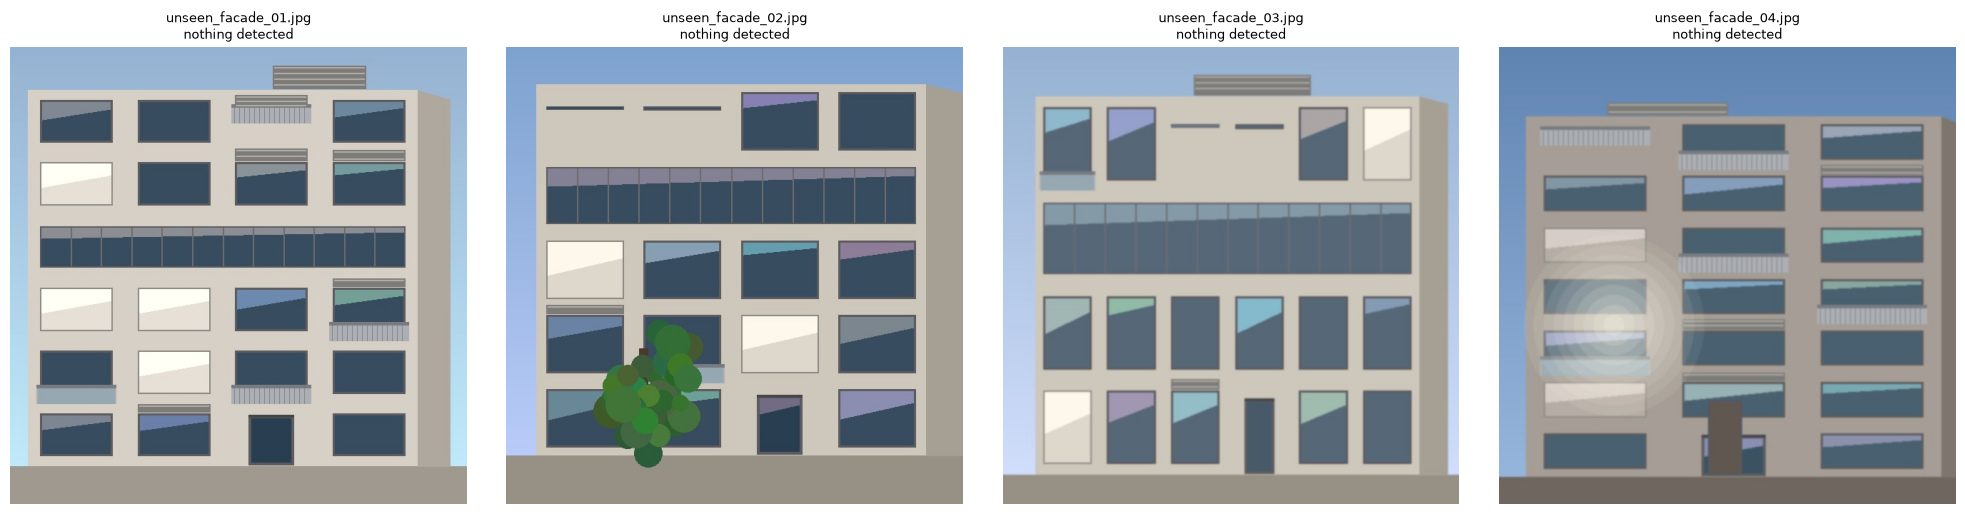

total detections across 4 façade images: 0


In [4]:
import matplotlib.pyplot as plt
from PIL import Image

results = coco.predict([str(p) for p in imgs[:4]], conf=0.25, verbose=False)

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
axes = [axes] if len(results) == 1 else axes
for ax, r, p in zip(axes, results, imgs):
    ax.imshow(Image.fromarray(r.plot()[:, :, ::-1]))
    found = [coco.names[int(b.cls)] for b in r.boxes]
    ax.set_title(f'{p.name}\n{found if found else "nothing detected"}', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

total = sum(len(r.boxes) for r in results)
print(f'total detections across {len(results)} façade images: {total}')


## 4 · The AECO reality check

Fill this in from what you just saw — it is the argument for the next notebook.

| Question | Answer |
|---|---|
| Did it detect the **building**? | Partly — sometimes as `train`, `bus` or `truck`, because those are the COCO classes with the right rectangular silhouette |
| Did it detect the **windows**? | No. There is no `window` class in COCO |
| Did it detect the **curtain wall**? | No |
| Did it detect the **balconies**? | No |
| Can it compute a Window-to-Wall Ratio? | **No** — and that is the only output the FMP's VE engine actually wants |

### Conclusion

Stock YOLOv8 is an excellent model that is useless for this problem. It is not
inaccurate — it is *answering a different question*. The fix is not a bigger model or
a lower confidence threshold. It is a **custom class contract and a custom dataset**:
[`docs/class_definitions.md`](../docs/class_definitions.md), then notebook `02`.

> This is the moment Session 1 is built around, and it is worth doing for real rather
> than taking on trust. A stakeholder who has seen the stock model fail on their own
> building understands immediately why annotation is worth paying for.
